In [27]:
!pip install seaborn

import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [56]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv", engine='python')

movies = movies.merge(credits, on='title')
movies.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [29]:
print("Dataset Shape:", movies.shape)
movies.info()

Dataset Shape: (4809, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   object 
 2   homepage              1713 non-null   object 
 3   id                    4809 non-null   int64  
 4   keywords              4809 non-null   object 
 5   original_language     4809 non-null   object 
 6   original_title        4809 non-null   object 
 7   overview              4806 non-null   object 
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   object 
 10  production_countries  4809 non-null   object 
 11  release_date          4808 non-null   object 
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   object 


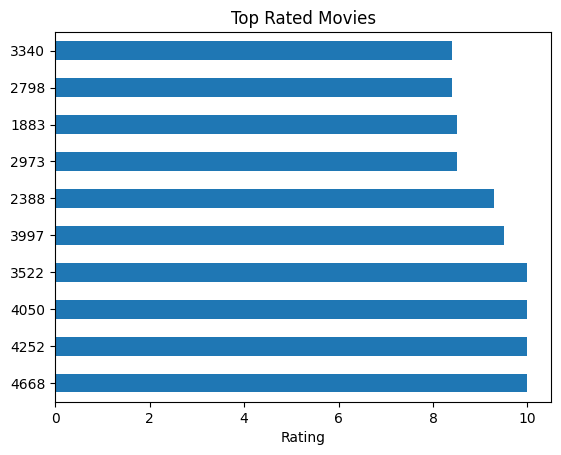

In [30]:
movies['vote_average'].sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Rated Movies")
plt.xlabel("Rating")
plt.show()

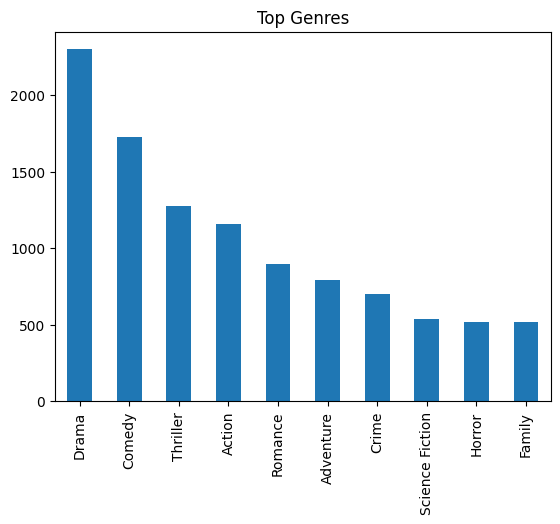

In [31]:
movies['genres'].head()

def extract_genres(text):
    genres = []
    for i in ast.literal_eval(text):
        genres.append(i['name'])
    return genres

movies['genres'] = movies['genres'].apply(extract_genres)

all_genres = sum(movies['genres'], [])
pd.Series(all_genres).value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

In [57]:
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew','vote_average']]

In [58]:
print(movies.columns)

Index(['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew',
       'vote_average'],
      dtype='object')


In [33]:
def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L

movies['keywords'] = movies['keywords'].apply(convert)

In [34]:
def convert_cast(text):
    L = []
    counter = 0
    for i in ast.literal_eval(text):
        if counter < 3:
            L.append(i['name'])
            counter += 1
        else:
            break
    return L

movies['cast'] = movies['cast'].apply(convert_cast)

In [35]:
def fetch_director(text):
    L = []
    for i in ast.literal_eval(text):
        if i['job'] == 'Director':
            L.append(i['name'])
            break
    return L

movies['crew'] = movies['crew'].apply(fetch_director)

In [36]:
movies['overview'] = movies['overview'].apply(lambda x: x.split())

movies['genres'] = movies['genres'].apply(lambda x: [i.replace(" ","") for i in x])
movies['keywords'] = movies['keywords'].apply(lambda x: [i.replace(" ","") for i in x])
movies['cast'] = movies['cast'].apply(lambda x: [i.replace(" ","") for i in x])
movies['crew'] = movies['crew'].apply(lambda x: [i.replace(" ","") for i in x])


In [37]:
movies['tags'] = (
    movies['overview'] +
    (movies['genres'] * 3) +
    (movies['keywords'] * 2) +
    (movies['cast'] * 2) +
    (movies['crew'] * 2)
)

In [38]:
new_df = movies[['movie_id','title','tags']].copy()
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))

In [39]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
vectors = tfidf.fit_transform(new_df['tags']).toarray()

In [40]:
similarity = cosine_similarity(vectors)


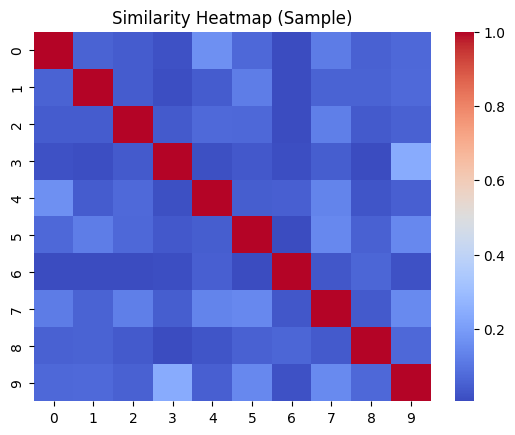

In [41]:
sns.heatmap(similarity[:10, :10], cmap='coolwarm')
plt.title("Similarity Heatmap (Sample)")
plt.show()

In [48]:
def recommend(movie, top_n=5):
    if movie not in new_df['title'].values:
        print("Movie not found")
        return

    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]

    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:top_n+1]

    print(f"\n🎬 Top {top_n} Recommendations for '{movie}':\n")

    for i, (idx, score) in enumerate(movies_list, start=1):
        print(f"{i}. {new_df.iloc[idx].title} ⭐ {round(float(score),3)}")

In [49]:
def recommend_with_popularity(movie, top_n=5):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]

    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:50]

    recs = []
    for idx, score in movie_list:
        title = new_df.iloc[idx].title
        rating = movies.iloc[idx]['vote_average']
        recs.append((title, score, rating))

    recs = sorted(recs, key=lambda x: (x[2], x[1]), reverse=True)[:top_n]

    print(f"\n🎬 Smart Recommendations:\n")
    for i, (title, sim, rating) in enumerate(recs, 1):
        print(f"{i}. {title} ⭐ Rating: {rating} | Sim: {round(float(sim),3)}")

In [50]:
def recommend_by_genre(genre, top_n=5):
    results = movies[movies['genres'].apply(lambda x: genre in x)]

    print(f"\n🎬 Top {genre} Movies:\n")
    top_movies = results.sort_values(by='vote_average', ascending=False).head(top_n)

    for i, title in enumerate(top_movies['title'], 1):
        print(f"{i}. {title}")

In [51]:
def recommend_table(movie, top_n=5):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]

    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:top_n+1]

    data = []
    for idx, score in movie_list:
        data.append({
            "Movie": new_df.iloc[idx].title,
            "Similarity Score": round(float(score), 3)
        })

    return pd.DataFrame(data)

In [52]:
def diverse_recommend(movie, top_n=5):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]

    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )

    selected = []
    genres_seen = set()

    for idx, score in movie_list[1:]:
        genres = set(movies.iloc[idx]['genres'])

        if not genres_seen.intersection(genres):
            selected.append((new_df.iloc[idx].title, score))
            genres_seen.update(genres)

        if len(selected) == top_n:
            break

    print("\n🎬 Diverse Recommendations:\n")
    for i, (title, score) in enumerate(selected, 1):
        print(f"{i}. {title} ({round(float(score),3)})")

In [59]:
recommend("Avatar")
recommend_with_popularity("Avatar")
recommend_by_genre("Action")
recommend_table("Avatar")
diverse_recommend("Avatar")


🎬 Top 5 Recommendations for 'Avatar':

1. Aliens ⭐ 0.292
2. Star Trek Into Darkness ⭐ 0.266
3. Barbarella ⭐ 0.212
4. Predators ⭐ 0.21
5. Cargo ⭐ 0.208

🎬 Smart Recommendations:

1. Falcon Rising ⭐ Rating: 8.2 | Sim: 0.194
2. Guardians of the Galaxy ⭐ Rating: 7.9 | Sim: 0.186
3. Aliens ⭐ Rating: 7.7 | Sim: 0.292
4. Edge of Tomorrow ⭐ Rating: 7.6 | Sim: 0.157
5. Star Trek Into Darkness ⭐ Rating: 7.4 | Sim: 0.266

🎬 Top Action Movies:

1. One Man's Hero
2. Seven Samurai
3. The Dark Knight
4. The Empire Strikes Back
5. Star Wars

🎬 Diverse Recommendations:

1. Aliens (0.292)


In [60]:
print("\n--- BASIC RECOMMENDATION ---")
recommend("Avatar")

print("\n--- POPULARITY BASED ---")
recommend_with_popularity("Avatar")

print("\n--- GENRE BASED ---")
recommend_by_genre("Action")

print("\n--- TABLE OUTPUT ---")
print(recommend_table("Avatar"))

print("\n--- DIVERSE RECOMMENDATION ---")
diverse_recommend("Avatar")


--- BASIC RECOMMENDATION ---

🎬 Top 5 Recommendations for 'Avatar':

1. Aliens ⭐ 0.292
2. Star Trek Into Darkness ⭐ 0.266
3. Barbarella ⭐ 0.212
4. Predators ⭐ 0.21
5. Cargo ⭐ 0.208

--- POPULARITY BASED ---

🎬 Smart Recommendations:

1. Falcon Rising ⭐ Rating: 8.2 | Sim: 0.194
2. Guardians of the Galaxy ⭐ Rating: 7.9 | Sim: 0.186
3. Aliens ⭐ Rating: 7.7 | Sim: 0.292
4. Edge of Tomorrow ⭐ Rating: 7.6 | Sim: 0.157
5. Star Trek Into Darkness ⭐ Rating: 7.4 | Sim: 0.266

--- GENRE BASED ---

🎬 Top Action Movies:

1. One Man's Hero
2. Seven Samurai
3. The Dark Knight
4. The Empire Strikes Back
5. Star Wars

--- TABLE OUTPUT ---
                     Movie  Similarity Score
0                   Aliens             0.292
1  Star Trek Into Darkness             0.266
2               Barbarella             0.212
3                Predators             0.210
4                    Cargo             0.208

--- DIVERSE RECOMMENDATION ---

🎬 Diverse Recommendations:

1. Aliens (0.292)
